# Hierarchical Risk Parity (HRP)

**Docker image**: `ml4t`

This notebook demonstrates Hierarchical Risk Parity, a modern portfolio construction
method developed by Marcos López de Prado that addresses the fundamental flaws of
Mean-Variance Optimization through clustering, quasi-diagonalization, and recursive bisection.

**Learning Objectives**:
- Understand why classical MVO fails in practice (the "Markowitz Curse")
- Implement the three steps of HRP: clustering, quasi-diagonalization, recursive bisection
- Visualize the asset hierarchy with dendrograms
- Run walk-forward backtests comparing HRP to MVO and heuristic allocators

**Book Reference**: Chapter 17, Section 17.6 (Hierarchical Risk Parity)

**Prerequisites**: `02_mean_variance_optimization`, ETF price data

## 1. Setup and Imports

In [1]:
"""Hierarchical Risk Parity (HRP) — cluster assets by correlation structure and allocate using inverse variance."""

import warnings

warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import polars as pl
from ml4t.backtest import (
    BacktestConfig,
    CommissionType,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.backtest.config import SlippageType
from ml4t.backtest.execution.rebalancer import RebalanceConfig, TargetWeightExecutor
from ml4t.diagnostic.evaluation import PortfolioAnalysis
from ml4t.diagnostic.visualization import create_portfolio_dashboard
from plotly.subplots import make_subplots
from scipy.cluster.hierarchy import dendrogram, leaves_list, linkage
from scipy.spatial.distance import squareform
from sklearn.covariance import LedoitWolf

from case_studies.utils.analytics import resolve_best_prediction
from case_studies.utils.backtest_loaders import compute_allocator_metrics
from data import load_etfs
from utils.paths import get_case_study_dir, get_output_dir
from utils.reproducibility import set_global_seeds

In [3]:
# Production defaults — Papermill overrides for CI testing
START_DATE = "2010-01-01"
SEED = 42

In [4]:
set_global_seeds(SEED)

# Track allocator fallbacks across the walk-forward backtest.
fallback_count: dict[str, int] = {}

## 2. The Problem: Why MVO Fails

MVO inverts a noisy covariance matrix and is acutely sensitive to estimation error,
which produces unstable, concentrated portfolios under regime shifts. See §17.6.

## 3. Data Acquisition

In [5]:
# Diversified ETF universe
ETF_UNIVERSE = {
    # US Equity
    "SPY": "S&P 500",
    "QQQ": "NASDAQ 100",
    "IWM": "Russell 2000",
    # International Equity
    "EFA": "EAFE Developed",
    "EEM": "Emerging Markets",
    # Fixed Income
    "AGG": "US Aggregate Bond",
    "TLT": "Long Treasury",
    "HYG": "High Yield",
    # Alternatives
    "GLD": "Gold",
    "VNQ": "Real Estate",
    "DBC": "Commodities",
    # Sectors
    "XLF": "Financials",
    "XLE": "Energy",
    "XLK": "Technology",
    "XLV": "Healthcare",
}

SYMBOLS = list(ETF_UNIVERSE.keys())
END_DATE = "2024-01-01"

In [6]:
# Load data from canonical ETFs
print("Loading ETF data...")
etf_data = load_etfs()
etf_filtered = etf_data.filter(
    (pl.col("symbol").is_in(SYMBOLS))
    & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_datetime())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_datetime())
)

close_prices = (
    etf_filtered.select(["timestamp", "symbol", "close"])
    .pivot(on="symbol", index="timestamp", values="close")
    .sort("timestamp")
    .to_pandas()
    .set_index("timestamp")
    .ffill()
    .dropna()
)
returns = close_prices.pct_change().dropna()
print(f"Loaded {len(returns):,} days for {close_prices.shape[1]} ETFs")

Loading ETF data...
Loaded 3,521 days for 15 ETFs


## 4. The HRP Algorithm

HRP works in three steps:

### Step 1: Tree Clustering
Build a hierarchy of assets based on their correlation structure using
agglomerative clustering.

### Step 2: Quasi-Diagonalization
Reorder the covariance matrix according to the clustering hierarchy
to group similar assets together.

### Step 3: Recursive Bisection
Allocate risk by recursively splitting the portfolio in half,
with weights inversely proportional to the cluster variance.

In [7]:
def correlation_distance(corr_matrix: np.ndarray) -> np.ndarray:
    """
    Convert correlation matrix to distance matrix.

    Distance = sqrt(0.5 * (1 - correlation))

    This ensures:
    - Perfectly correlated assets have distance 0
    - Uncorrelated assets have distance ~0.707
    - Perfectly anti-correlated assets have distance 1
    """
    return np.sqrt(0.5 * (1 - corr_matrix))

#### Step 1: Hierarchical Clustering

In [8]:
def cluster_assets(returns: pd.DataFrame, method: str = "ward") -> np.ndarray:
    """
    Perform hierarchical clustering on assets based on correlation distance.

    Args:
        returns: DataFrame of asset returns
        method: Linkage method ('ward', 'single', 'complete', 'average')

    Returns:
        linkage matrix
    """
    corr = returns.corr().values
    dist = correlation_distance(corr)
    # Convert to condensed distance matrix (upper triangle)
    dist_condensed = squareform(dist, checks=False)
    return linkage(dist_condensed, method=method)

#### Step 2: Leaf Ordering

In [9]:
def get_quasi_diagonal_order(link: np.ndarray, n_assets: int) -> list[int]:
    """
    Get the quasi-diagonal ordering from linkage matrix.

    This reorders assets so that similar ones are adjacent.
    """
    return list(leaves_list(link))

#### Cluster Risk Helper

In [10]:
def cluster_variance(cov: np.ndarray, indices: list[int]) -> float:
    """Compute cluster variance using inverse-variance weights within a subset."""
    if len(indices) == 1:
        return float(cov[indices[0], indices[0]])
    c = cov[np.ix_(indices, indices)]
    ivp = 1 / np.diag(c)
    ivp /= ivp.sum()
    return float(np.dot(ivp, np.dot(c, ivp)))

#### Step 3: Recursive Bisection Allocation

In [11]:
def recursive_bisection(
    cov: np.ndarray,
    sorted_idx: list[int],
) -> np.ndarray:
    """Allocate weights by recursively splitting ordered clusters."""
    n = len(sorted_idx)
    weights = np.ones(n)

    clusters = [sorted_idx]

    while clusters:
        new_clusters = []
        for cluster in clusters:
            if len(cluster) <= 1:
                continue

            mid = len(cluster) // 2
            left = cluster[:mid]
            right = cluster[mid:]

            left_var = cluster_variance(cov, left)
            right_var = cluster_variance(cov, right)

            alpha = 1 - left_var / (left_var + right_var)
            for i in left:
                weights[sorted_idx.index(i)] *= alpha
            for i in right:
                weights[sorted_idx.index(i)] *= 1 - alpha

            if len(left) > 1:
                new_clusters.append(left)
            if len(right) > 1:
                new_clusters.append(right)

        clusters = new_clusters

    final_weights = np.zeros(n)
    for i, orig_idx in enumerate(sorted_idx):
        final_weights[orig_idx] = weights[i]

    return final_weights / final_weights.sum()

### HRP Weight Computation Wrapper

In [12]:
def hrp_portfolio(returns: pd.DataFrame) -> np.ndarray:
    """
    Compute HRP portfolio weights.

    Args:
        returns: DataFrame of asset returns

    Returns:
        Array of portfolio weights
    """
    # Step 1: Cluster
    link = cluster_assets(returns)

    # Step 2: Quasi-diagonalize
    sorted_idx = get_quasi_diagonal_order(link, len(returns.columns))

    # Step 3: Recursive bisection
    cov = returns.cov().values
    weights = recursive_bisection(cov, sorted_idx)

    return weights

## 5. Visualizing the Asset Hierarchy

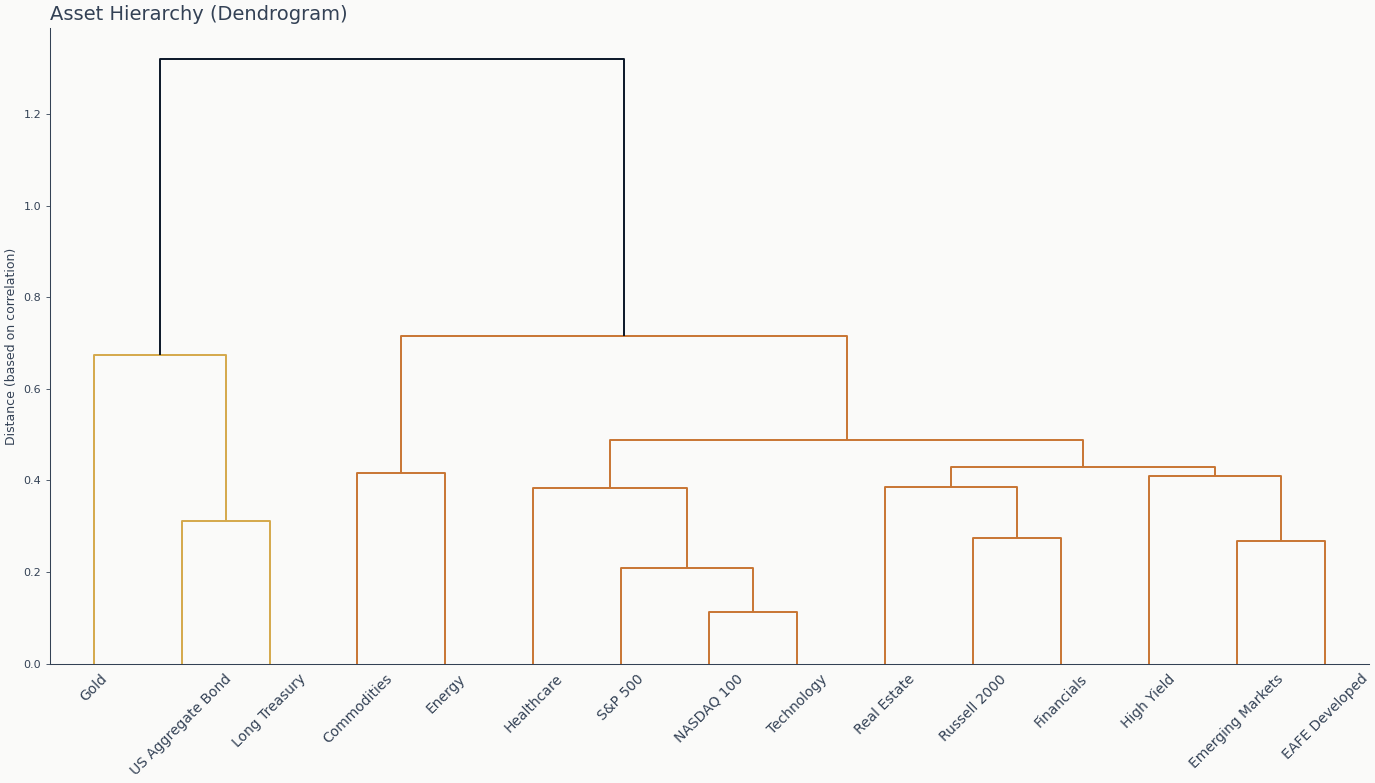

In [13]:
# Compute linkage for visualization
link = cluster_assets(returns)

# Create dendrogram
fig, ax = plt.subplots(figsize=(14, 8))
dn = dendrogram(
    link,
    labels=[ETF_UNIVERSE.get(s, s) for s in returns.columns],
    leaf_rotation=45,
    leaf_font_size=10,
    ax=ax,
)
ax.set_title("Asset Hierarchy (Dendrogram)", fontsize=14)
ax.set_ylabel("Distance (based on correlation)")
plt.tight_layout()
plt.show()

### Interactive Dendrogram

In [14]:
def plotly_dendrogram(link, labels, title="Asset Hierarchy"):
    """Create interactive dendrogram with Plotly."""
    # Get dendrogram coordinates
    dn = dendrogram(link, labels=labels, no_plot=True)

    # Create traces
    traces = []
    for i in range(len(dn["icoord"])):
        traces.append(
            go.Scatter(
                x=dn["icoord"][i],
                y=dn["dcoord"][i],
                mode="lines",
                line=dict(color="steelblue", width=1.5),
                hoverinfo="skip",
            )
        )

    # Create figure
    fig = go.Figure(data=traces)

    # Add labels at bottom
    fig.update_layout(
        title=title,
        xaxis=dict(
            tickmode="array",
            tickvals=list(range(5, 10 * len(labels), 10)),
            ticktext=[labels[i] for i in dn["leaves"]],
            tickangle=45,
        ),
        yaxis_title="Correlation Distance",
        height=500,
        showlegend=False,
    )

    return fig

Build and render the interactive dendrogram for the ETF universe.

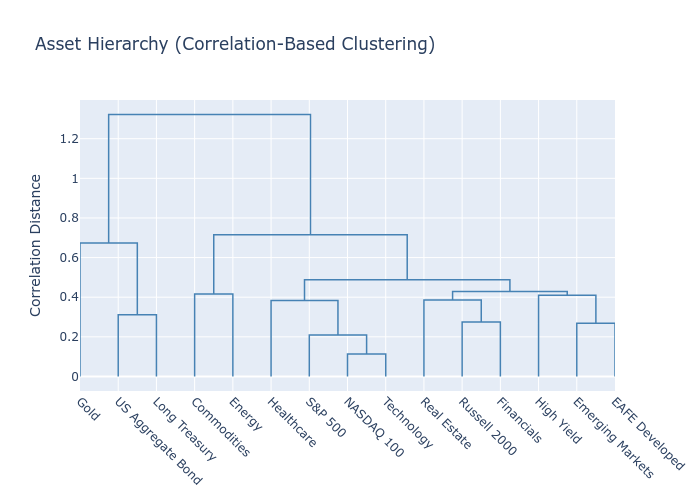

In [15]:
labels = [ETF_UNIVERSE.get(s, s) for s in returns.columns]
fig = plotly_dendrogram(link, labels, "Asset Hierarchy (Correlation-Based Clustering)")
fig.show()

## 6. Quasi-Diagonal Covariance Matrix

After clustering, we reorder the covariance matrix to reveal the block structure.

In [16]:
# Get quasi-diagonal ordering
sorted_idx = get_quasi_diagonal_order(link, len(returns.columns))
sorted_symbols = [returns.columns[i] for i in sorted_idx]
sorted_labels = [ETF_UNIVERSE.get(s, s) for s in sorted_symbols]

# Reorder covariance matrix
cov_original = returns.cov()
cov_reordered = cov_original.iloc[sorted_idx, sorted_idx]

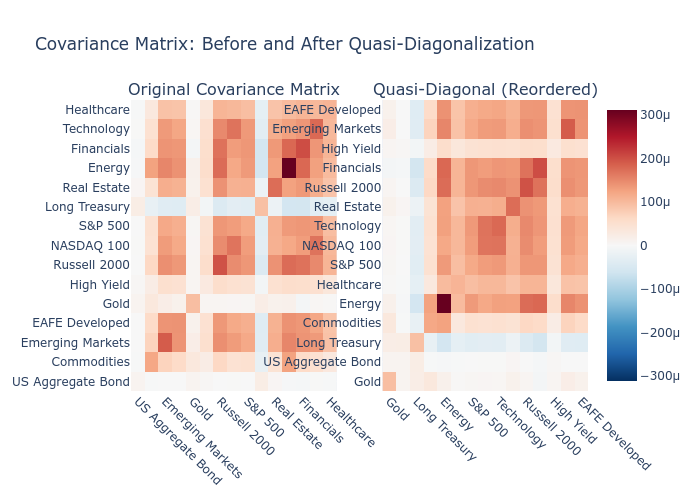

In [17]:
# Visualization
fig = make_subplots(
    rows=1, cols=2, subplot_titles=["Original Covariance Matrix", "Quasi-Diagonal (Reordered)"]
)

# Original
fig.add_trace(
    go.Heatmap(
        z=cov_original.values,
        x=[ETF_UNIVERSE.get(s, s) for s in cov_original.columns],
        y=[ETF_UNIVERSE.get(s, s) for s in cov_original.index],
        colorscale="RdBu_r",
        zmid=0,
        showscale=False,
    ),
    row=1,
    col=1,
)

# Reordered
fig.add_trace(
    go.Heatmap(
        z=cov_reordered.values,
        x=sorted_labels,
        y=sorted_labels,
        colorscale="RdBu_r",
        zmid=0,
        showscale=True,
    ),
    row=1,
    col=2,
)

fig.update_layout(
    title="Covariance Matrix: Before and After Quasi-Diagonalization",
    height=500,
)
fig.update_xaxes(tickangle=45)
fig.show()

## 7. Compute HRP Weights

In [18]:
# Compute HRP weights
hrp_weights = hrp_portfolio(returns)

# Create weights DataFrame
weights_df = pd.DataFrame(
    {
        "Symbol": returns.columns,
        "Name": [ETF_UNIVERSE.get(s, s) for s in returns.columns],
        "HRP Weight": hrp_weights,
    }
)
weights_df = weights_df.sort_values("HRP Weight", ascending=False)
weights_df

,Symbol,Name,HRP Weight
0,AGG,US Aggregate Bond,0.632424
4,GLD,Gold,0.083632
5,HYG,High Yield,0.062150
9,TLT,Long Treasury,0.058981
1,DBC,Commodities,0.031953
14,XLV,Healthcare,0.030978
8,SPY,S&P 500,0.027752
11,XLE,Energy,0.012395
3,EFA,EAFE Developed,0.010516
12,XLF,Financials,0.009209


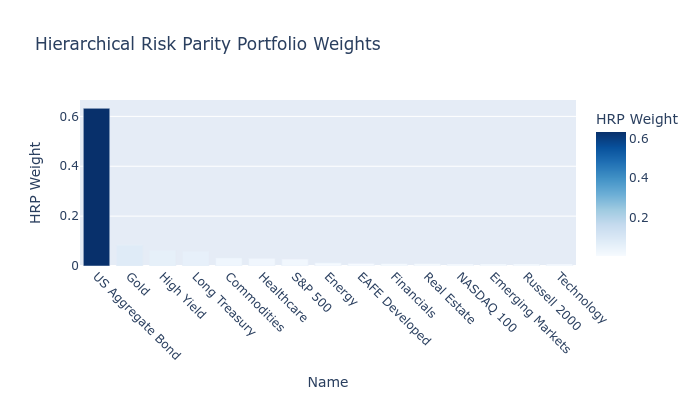

In [19]:
# Visualization
fig = px.bar(
    weights_df,
    x="Name",
    y="HRP Weight",
    title="Hierarchical Risk Parity Portfolio Weights",
    color="HRP Weight",
    color_continuous_scale="Blues",
)
fig.update_layout(
    height=400,
    xaxis_tickangle=45,
)
fig.show()

## 8. Comparison: HRP vs Other Methods

In [20]:
def inverse_volatility_weights(returns: pd.DataFrame) -> np.ndarray:
    """Inverse volatility (risk parity) weights."""
    vols = returns.std().values
    inv_vols = 1 / vols
    return inv_vols / inv_vols.sum()

#### Equal-Weight Baseline

In [21]:
def equal_weights(n: int) -> np.ndarray:
    """Equal weights."""
    return np.ones(n) / n

#### Minimum-Variance Baseline

In [22]:
def minimum_variance_weights(returns: pd.DataFrame) -> np.ndarray:
    """Minimum variance portfolio (no expected returns input)."""
    cov = returns.cov().values
    n = len(returns.columns)

    # Solve: min w'Σw s.t. sum(w) = 1
    # Closed-form: w = Σ^{-1} 1 / (1' Σ^{-1} 1)
    try:
        cov_inv = np.linalg.inv(cov)
        ones = np.ones(n)
        weights = cov_inv @ ones
        weights /= weights.sum()
        # Long-only projection: clip negatives, then renormalize so weights sum to 1
        weights = np.clip(weights, 0, None)
        total = weights.sum()
        return weights / total if total > 0 else equal_weights(n)
    except np.linalg.LinAlgError:
        return equal_weights(n)

#### Ledoit-Wolf Shrinkage Baseline

In [23]:
def mvo_shrinkage_weights(returns: pd.DataFrame) -> np.ndarray:
    """MVO with Ledoit-Wolf shrinkage."""
    # Use Ledoit-Wolf for robust covariance
    lw = LedoitWolf().fit(returns)
    cov_shrunk = lw.covariance_

    # Minimum variance with shrunk covariance
    n = len(returns.columns)
    try:
        cov_inv = np.linalg.inv(cov_shrunk)
        ones = np.ones(n)
        weights = cov_inv @ ones
        weights /= weights.sum()
        # Long-only projection: clip negatives, then renormalize so weights sum to 1
        weights = np.clip(weights, 0, None)
        total = weights.sum()
        return weights / total if total > 0 else equal_weights(n)
    except np.linalg.LinAlgError:
        return equal_weights(n)

In [24]:
# Compute all weights
n_assets = len(returns.columns)

all_weights = pd.DataFrame(
    {
        "Symbol": returns.columns,
        "Name": [ETF_UNIVERSE.get(s, s) for s in returns.columns],
        "Equal": equal_weights(n_assets),
        "Inv Vol": inverse_volatility_weights(returns),
        "Min Var (LW)": mvo_shrinkage_weights(returns),
        "HRP": hrp_weights,
    }
)

all_weights.round(4)

,Symbol,Name,Equal,Inv Vol,Min Var (LW),HRP
0,AGG,US Aggregate Bond,0.0667,0.2131,0.7945,0.6324
1,DBC,Commodities,0.0667,0.0573,0.0341,0.0320
2,EEM,Emerging Markets,0.0667,0.0457,0.0000,0.0078
3,EFA,EAFE Developed,0.0667,0.0531,0.0000,0.0105
4,GLD,Gold,0.0667,0.0644,0.0023,0.0836
5,HYG,High Yield,0.0667,0.1149,0.0828,0.0622
6,IWM,Russell 2000,0.0667,0.0447,0.0000,0.0077
7,QQQ,NASDAQ 100,0.0667,0.0485,0.0000,0.0081
8,SPY,S&P 500,0.0667,0.0577,0.0234,0.0278
9,TLT,Long Treasury,0.0667,0.0651,0.0000,0.0590


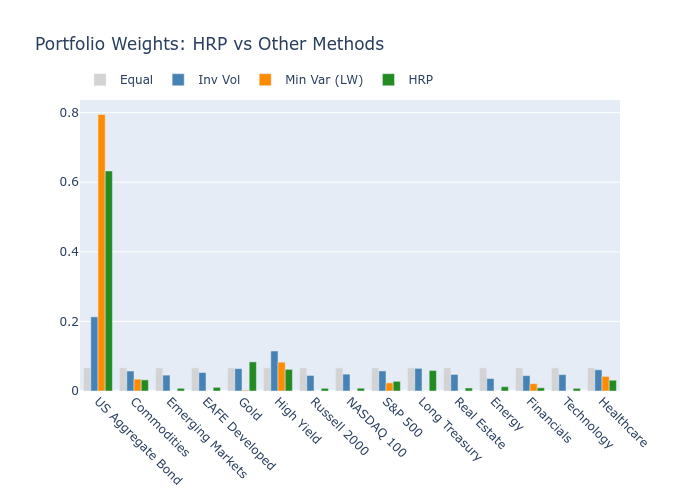

In [25]:
# Visualization: Weight comparison
fig = go.Figure()

methods = ["Equal", "Inv Vol", "Min Var (LW)", "HRP"]
colors = ["lightgray", "steelblue", "darkorange", "forestgreen"]

for method, color in zip(methods, colors, strict=False):
    fig.add_trace(
        go.Bar(
            name=method,
            x=all_weights["Name"],
            y=all_weights[method],
            marker_color=color,
        )
    )

fig.update_layout(
    title="Portfolio Weights: HRP vs Other Methods",
    barmode="group",
    xaxis_tickangle=45,
    height=500,
    legend=dict(orientation="h", yanchor="bottom", y=1.02),
)
fig.show()

## 9. Walk-Forward Backtest with ML Predictions

The previous sections demonstrated *how* HRP allocates capital given a
covariance matrix. We now apply it inside a realistic trading strategy:

1. Load the ETF case-study GBM walk-forward predictions (Chapter 12).
2. At each rebalance date, use the latest available prediction to *select* the
   top-$N$ assets.
3. Apply HRP (and the other methods) to the selected subset using only
   historical returns for covariance estimation.

Asset selection is therefore driven by an out-of-sample ML signal, while the
allocator only sees information available at the rebalance date.

In [26]:
# We use the ETF case study's best-IC GBM walk-forward predictions for asset
# selection. HRP itself only needs a covariance matrix; using real upstream
# predictions keeps the asset-selection step honest and aligned with the
# case-study story. The highest-validation-IC GBM checkpoint is resolved at runtime from
# `case_studies/etfs/run_log/registry.db` — there is no baked-in `prediction_hash`,
# so re-running the GBM sweep automatically updates which predictions feed HRP.
best_gbm = resolve_best_prediction("etfs", "fwd_ret_21d", family="gbm")
ETF_GBM_PRED_HASH = best_gbm["prediction_hash"]
PRED_PATH = (
    get_case_study_dir("etfs")
    / "run_log"
    / "predictions"
    / ETF_GBM_PRED_HASH
    / "predictions.parquet"
)
if not PRED_PATH.exists():
    raise FileNotFoundError(
        f"Resolved best-IC GBM hash {ETF_GBM_PRED_HASH} (config={best_gbm['config_name']}) "
        f"has no predictions parquet at {PRED_PATH}. Re-run case_studies/etfs/07_gbm.py."
    )
print(
    f"Resolved best-IC GBM: hash={ETF_GBM_PRED_HASH}, config={best_gbm['config_name']}, "
    f"IC={best_gbm['ic_mean']:.4f}"
)

upstream_preds = pl.read_parquet(PRED_PATH).select("timestamp", "symbol", "prediction")
print(
    f"Loaded ETF GBM predictions: {upstream_preds.height:,} rows, "
    f"{upstream_preds['symbol'].n_unique()} symbols, "
    f"{upstream_preds['timestamp'].min()} → {upstream_preds['timestamp'].max()}"
)

Resolved best-IC GBM: hash=e716461a3d25, config=leaves_7_mse, IC=0.0371
Loaded ETF GBM predictions: 190,234 rows, 99 symbols, 2015-12-28 00:00:00 → 2023-12-29 00:00:00


### Asset Selection Rule

At each rebalance date we take the most recent prediction available for each
symbol (as-of join), rank by predicted return, and select the top $N$ that
are present in the historical return panel. If no prediction is available
yet for the date (e.g., before the first walk-forward fold), the rebalance
is skipped by returning an empty list.

In [27]:
def select_top_assets(
    hist_returns: pd.DataFrame,
    date: pd.Timestamp,
    full_returns: pd.DataFrame,
    predictions: pl.DataFrame,
    top_n: int,
) -> list[str]:
    """Select top-N assets by latest available GBM prediction at `date`.

    Polars `group_by` does not guarantee row order, and ties at the top-N
    cutoff would otherwise produce non-deterministic selections across runs.
    We secondary-sort by symbol so the selection is reproducible.
    """
    as_of = predictions.filter(pl.col("timestamp") <= date)
    if as_of.is_empty():
        return []
    latest = (
        as_of.sort("timestamp")
        .group_by("symbol")
        .agg(pl.col("prediction").last())
        .sort(["prediction", "symbol"], descending=[True, False])
    )
    ranked = latest.head(top_n)["symbol"].to_list()
    return [asset for asset in ranked if asset in full_returns.columns][:top_n]

### Allocation Mapping Helper

In [28]:
def allocate_selected_assets(
    full_columns: pd.Index,
    top_assets: list[str],
    selected_returns: pd.DataFrame,
    allocation_fn,
    method: str = "allocator",
    date: pd.Timestamp | None = None,
) -> pd.Series:
    """Apply allocation function and map selected weights back to full universe.

    On a singular/invalid covariance the allocator falls back to equal weights,
    warns at the call site, and increments the module-level ``fallback_count``
    so the notebook reports how often each method needed the fallback.
    """
    weights = pd.Series(0.0, index=full_columns)
    try:
        alloc_weights = allocation_fn(selected_returns)
        for asset, weight in zip(top_assets, alloc_weights, strict=False):
            weights[asset] = weight
    except (np.linalg.LinAlgError, ValueError) as exc:
        warnings.warn(
            f"{method} singular/invalid for {len(top_assets)} assets at {date}: {exc}",
            RuntimeWarning,
            stacklevel=2,
        )
        fallback_count[method] = fallback_count.get(method, 0) + 1
        for asset in top_assets:
            weights[asset] = 1.0 / len(top_assets)
    return weights

### Walk-Forward Backtest Engine

In [29]:
def walk_forward_backtest(
    returns: pd.DataFrame,
    allocation_fn,
    predictions: pl.DataFrame | None = None,
    lookback: int = 252,
    rebalance_freq: str = "ME",
    top_n: int = 5,
    method: str = "allocator",
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Walk-forward backtest with historical-only allocation inputs."""
    rebalance_dates = returns.resample(rebalance_freq).last().index
    portfolio_returns = []
    weights_history = []
    current_weights = pd.Series(1.0 / len(returns.columns), index=returns.columns)

    for date in returns.index:
        if date in rebalance_dates:
            loc = returns.index.get_loc(date)
            lookback_start = max(0, loc - lookback)
            hist_returns = returns.iloc[lookback_start:loc]
            if len(hist_returns) < 60:
                continue
            top_assets = select_top_assets(hist_returns, date, returns, predictions, top_n)
            if len(top_assets) < 2:
                continue

            selected_returns = hist_returns[top_assets]
            current_weights = allocate_selected_assets(
                returns.columns,
                top_assets,
                selected_returns,
                allocation_fn,
                method=method,
                date=date,
            )

        daily_ret = (returns.loc[date] * current_weights).sum()
        portfolio_returns.append({"date": date, "return": daily_ret})
        weights_history.append(
            {"date": date, **{f"w_{s}": current_weights[s] for s in returns.columns}}
        )

    return (
        pd.DataFrame(portfolio_returns).set_index("date"),
        pd.DataFrame(weights_history).set_index("date"),
    )

In [30]:
# Run walk-forward backtests for all allocation methods
allocation_methods = {
    "Equal Weight": lambda r: equal_weights(len(r.columns)),
    "Inverse Volatility": inverse_volatility_weights,
    "Min Variance (LW)": mvo_shrinkage_weights,
    "HRP": hrp_portfolio,
}

results = {}
weights_all = {}

print("Running walk-forward backtests...")
for name, alloc_fn in allocation_methods.items():
    print(f"  {name}...")
    ret_df, w_df = walk_forward_backtest(
        returns=returns,
        allocation_fn=alloc_fn,
        predictions=upstream_preds,
        lookback=252,
        rebalance_freq="ME",
        top_n=5,
        method=name,
    )
    results[name] = ret_df["return"]
    weights_all[name] = w_df

print("All backtests complete")

# Combine into DataFrame
portfolio_returns = pd.DataFrame(results)

Running walk-forward backtests...
  Equal Weight...


  Inverse Volatility...


  Min Variance (LW)...


  HRP...


All backtests complete


### Backtest Metrics

In [31]:
def _weights_wide_to_long(weights_df: pd.DataFrame) -> pl.DataFrame:
    """Convert wide [w_SYMBOL] matrix to [timestamp, asset, weight] format."""
    wide = weights_df.reset_index()
    ts_col = wide.columns[0]
    wide = wide.rename(columns={ts_col: "timestamp"})
    long = wide.melt(id_vars=["timestamp"], var_name="symbol", value_name="weight")
    long["symbol"] = long["symbol"].str.replace("w_", "", regex=False)
    long = long[long["weight"] != 0.0]
    return pl.from_pandas(long[["timestamp", "symbol", "weight"]])

Compute allocator metrics (Sharpe, drawdown, turnover) for each method.

In [32]:
allocator_metrics: dict[str, dict] = {}
metrics_list = []
for name in portfolio_returns.columns:
    returns_arr = portfolio_returns[name].to_numpy()
    weights_long = _weights_wide_to_long(weights_all[name])
    m = compute_allocator_metrics(
        pl.Series("returns", returns_arr),
        weights_df=weights_long,
        ann_factor=np.sqrt(252),
    )
    allocator_metrics[name] = m
    finite = returns_arr[np.isfinite(returns_arr)]
    annual_vol = float(np.nanstd(finite, ddof=1) * np.sqrt(252)) if finite.size > 1 else 0.0
    metrics_list.append(
        {
            "Method": name,
            "Annual Return": m["annual_return"],
            "Annual Vol": annual_vol,
            "Sharpe Ratio": m["sharpe"],
            "Max Drawdown": m["max_drawdown"],
            "Calmar Ratio": m["calmar"],
        }
    )

Assemble the comparison table and display.

In [33]:
metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df[
    ["Method", "Annual Return", "Annual Vol", "Sharpe Ratio", "Max Drawdown", "Calmar Ratio"]
]
metrics_df.round(4)

,Method,Annual Return,Annual Vol,Sharpe Ratio,Max Drawdown,Calmar Ratio
0,Equal Weight,0.1038,0.1398,0.7763,-0.2806,0.3698
1,Inverse Volatility,0.1092,0.1408,0.8074,-0.2806,0.3893
2,Min Variance (LW),0.1183,0.1451,0.8437,-0.2806,0.4215
3,HRP,0.1141,0.1426,0.8293,-0.2806,0.4065


### Scheduled Weight Strategy

This adapter converts the notebook's target-weight schedule into the
event-driven strategy interface expected by `ml4t-backtest`.

In [34]:
class ScheduledWeightStrategy(Strategy):
    def __init__(self, weights_long: pl.DataFrame, allow_short: bool):
        self.executor = TargetWeightExecutor(
            config=RebalanceConfig(
                min_trade_value=100.0,
                min_weight_change=0.001,
                allow_fractional=True,
                allow_short=allow_short,
            )
        )
        self._targets_by_ts: dict[pd.Timestamp, dict[str, float]] = {}
        for row in weights_long.iter_rows(named=True):
            ts = pd.Timestamp(row["timestamp"]).tz_localize(None)
            self._targets_by_ts.setdefault(ts, {})
            weight = float(row["weight"])
            if weight != 0.0:
                self._targets_by_ts[ts][str(row["symbol"])] = weight

    def on_data(self, timestamp, data, context, broker):
        ts = pd.Timestamp(timestamp).tz_localize(None)
        targets = self._targets_by_ts.get(ts)
        if not targets:
            return
        targets = {asset: weight for asset, weight in targets.items() if asset in data}
        if targets:
            self.executor.execute(targets, data, broker)

### Build Engine Inputs

Convert the wide notebook outputs into the long-form price and target tables
required by the execution engine.

In [35]:
bridge_method = "HRP" if "HRP" in weights_all else next(iter(weights_all))
weights_long = _weights_wide_to_long(weights_all[bridge_method]).with_columns(
    pl.col("timestamp").cast(pl.Datetime("us"))
)
allow_short_engine = (
    weights_long.filter(pl.col("weight") < 0).height > 0 if not weights_long.is_empty() else False
)

prices_panel = pl.from_pandas(close_prices.reset_index())
ts_col = prices_panel.columns[0]
if ts_col != "timestamp":
    prices_panel = prices_panel.rename({ts_col: "timestamp"})
prices_long = (
    prices_panel.unpivot(index="timestamp", variable_name="symbol", value_name="close")
    .with_columns(
        [
            pl.col("timestamp").cast(pl.Datetime("us")),
            pl.col("close").alias("open"),
            pl.col("close").alias("high"),
            pl.col("close").alias("low"),
            pl.lit(1_000_000).alias("volume"),
        ]
    )
    .sort(["timestamp", "symbol"])
)

### Run the Execution-Aware Backtest

Replay the same target weights with commissions, slippage, and next-bar fills.

In [36]:
engine = Engine(
    feed=DataFeed(prices_df=prices_long),
    strategy=ScheduledWeightStrategy(weights_long, allow_short=allow_short_engine),
    config=BacktestConfig(
        initial_cash=100_000.0,
        execution_mode=ExecutionMode.NEXT_BAR,
        commission_type=CommissionType.PERCENTAGE,
        commission_rate=0.0005,
        slippage_type=SlippageType.PERCENTAGE,
        slippage_rate=0.0005,
        allow_short_selling=allow_short_engine,
    ),
)

### Compare Engine and Vectorized Returns

The bridge checks whether the event-driven backtest preserves the ranking and
risk shape implied by the vectorized walk-forward simulation.

In [37]:
engine_daily = (
    engine.run()
    .to_daily_pnl()
    .select(
        pl.col("date").cast(pl.Datetime("us")).alias("date"),
        pl.col("return_pct").alias("engine_return"),
    )
)
vectorized_daily = pl.DataFrame(
    {
        "date": pl.Series(portfolio_returns.index.to_list()).cast(pl.Datetime("us")),
        "vectorized_return": portfolio_returns[bridge_method].to_numpy(),
    }
)

bridge = (
    vectorized_daily.join(engine_daily, on="date", how="inner")
    .drop_nulls(["vectorized_return", "engine_return"])
    .sort("date")
)

vec_summary = PortfolioAnalysis(returns=bridge["vectorized_return"], periods_per_year=252)
eng_summary = PortfolioAnalysis(returns=bridge["engine_return"], periods_per_year=252)
vec_stats = vec_summary.compute_summary_stats()
eng_stats = eng_summary.compute_summary_stats()

print(f"\nExecution bridge ({bridge_method} walk-forward):")
print(
    f"  Vectorized Sharpe={vec_stats.sharpe_ratio:.3f}, Engine Sharpe={eng_stats.sharpe_ratio:.3f}"
)
print(f"  Vectorized MaxDD={vec_stats.max_drawdown:.2%}, Engine MaxDD={eng_stats.max_drawdown:.2%}")


Execution bridge (HRP walk-forward):
  Vectorized Sharpe=0.829, Engine Sharpe=0.803
  Vectorized MaxDD=-28.06%, Engine MaxDD=-28.48%


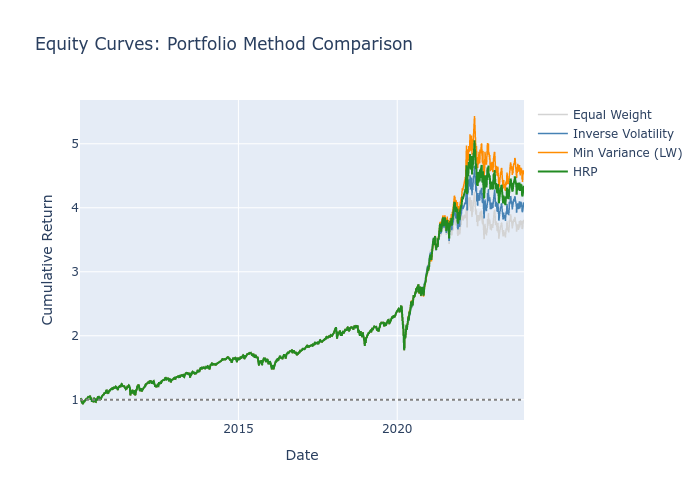

In [38]:
# Equity curves
cumulative = (1 + portfolio_returns).cumprod()

fig = go.Figure()

for col, color in zip(
    cumulative.columns, ["lightgray", "steelblue", "darkorange", "forestgreen"], strict=False
):
    fig.add_trace(
        go.Scatter(
            x=cumulative.index,
            y=cumulative[col],
            mode="lines",
            name=col,
            line=dict(color=color, width=2 if col == "HRP" else 1.5),
        )
    )

fig.add_hline(y=1.0, line_dash="dot", line_color="gray")

fig.update_layout(
    title="Equity Curves: Portfolio Method Comparison",
    xaxis_title="Date",
    yaxis_title="Cumulative Return",
    height=500,
)
fig.show()

## 10. Tear Sheet — `ml4t-diagnostic`

`ml4t-diagnostic` exposes two delivery modes for the same analysis surface:

- **Inline** — `create_portfolio_dashboard(analysis).show()` renders the
  metrics block plus each Plotly figure (cumulative returns, drawdown
  underwater, rolling Sharpe, monthly heatmap, returns distribution, etc.) as
  normal notebook cell outputs.
- **HTML** — `tear_sheet.save_html(path)` writes a self-contained file that
  embeds the same content for sharing or archival.

We build the analysis on the HRP walk-forward returns versus SPY (the same
benchmark the chapter prose uses). The tear sheet metrics are computed from
the strategy series, so they will track the table above to within rounding.

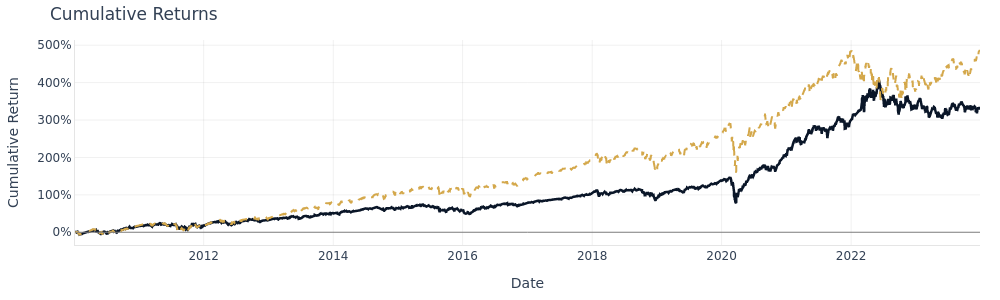

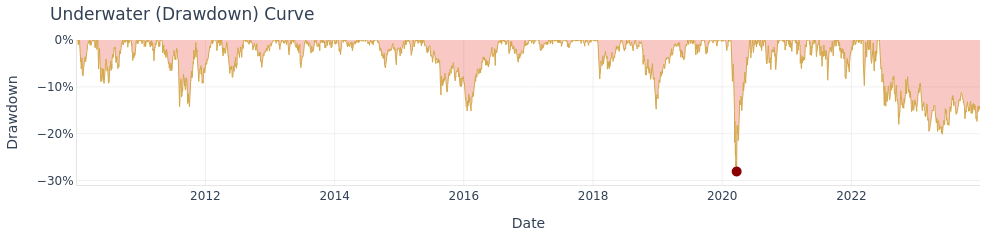

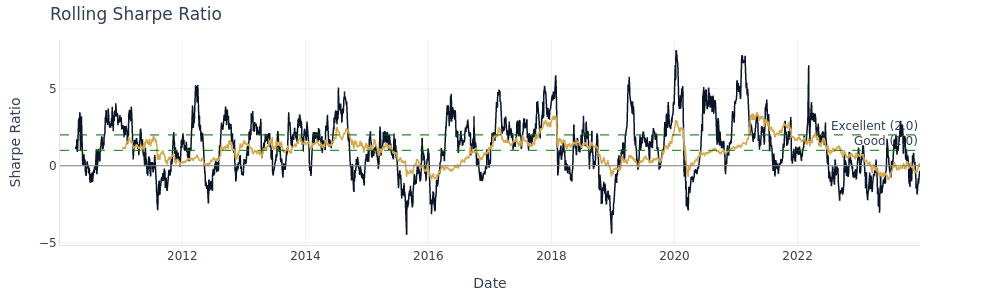

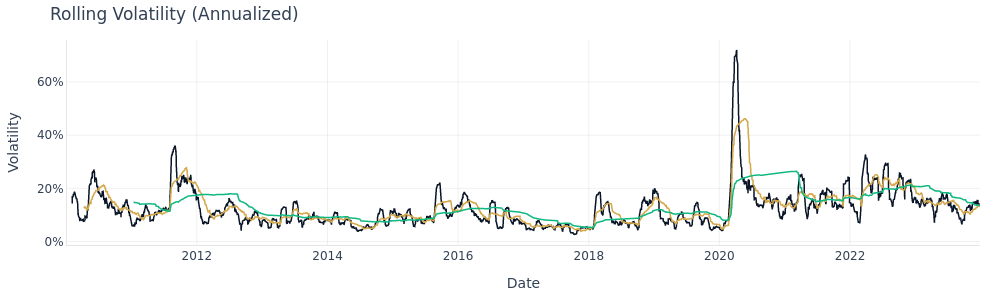

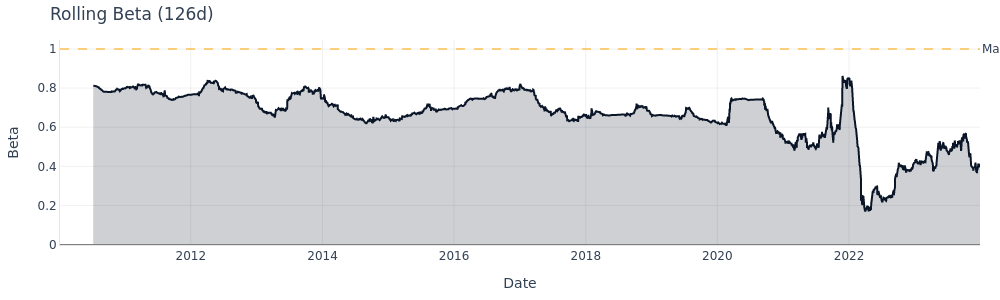

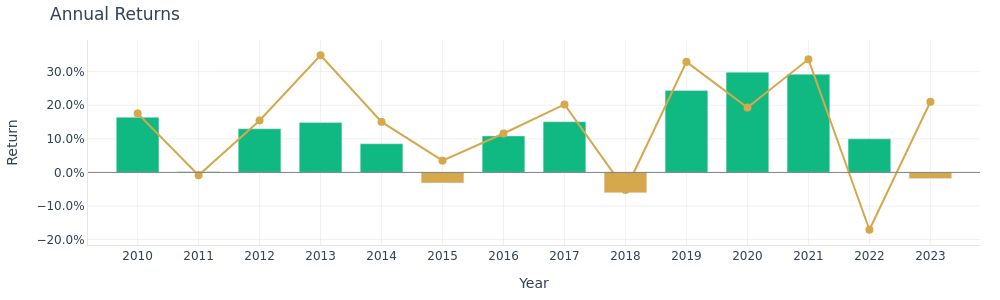

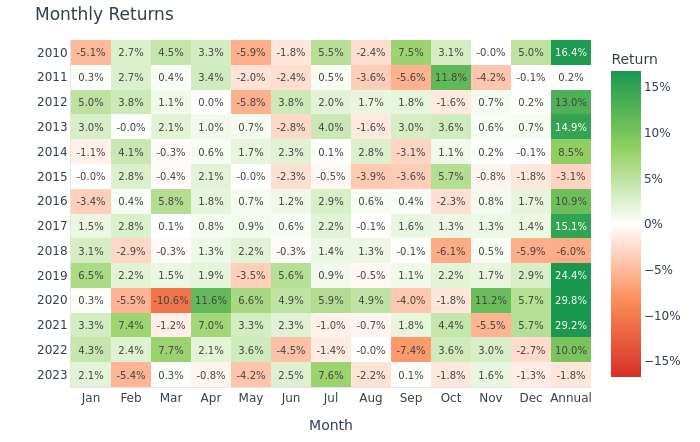

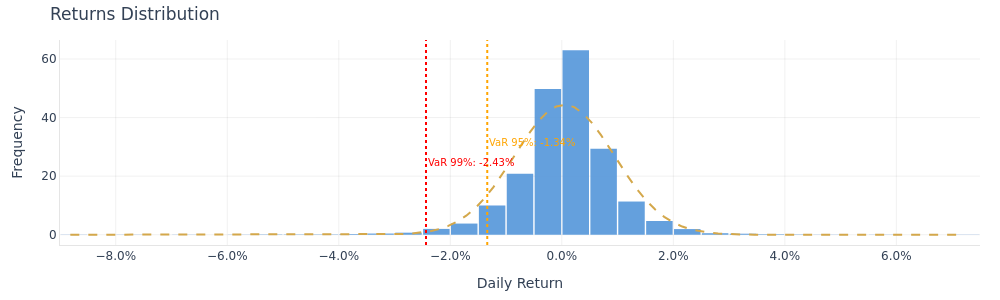

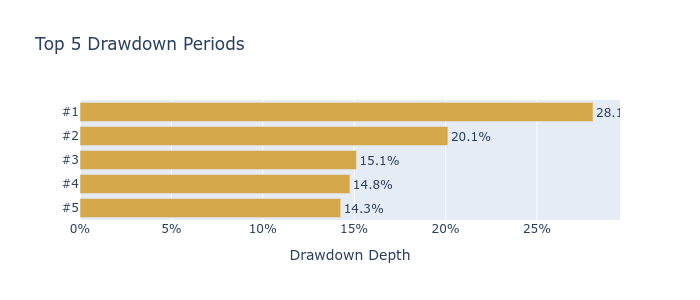

In [39]:
hrp_returns_series = portfolio_returns["HRP"].dropna()
spy_returns_series = returns["SPY"].reindex(hrp_returns_series.index).dropna()
common_idx = hrp_returns_series.index.intersection(spy_returns_series.index)

hrp_analysis = PortfolioAnalysis(
    returns=hrp_returns_series.loc[common_idx].to_numpy(),
    benchmark=spy_returns_series.loc[common_idx].to_numpy(),
    dates=common_idx,
    risk_free=0.0,
    periods_per_year=252,
)

hrp_tear_sheet = create_portfolio_dashboard(hrp_analysis)

# Inline display: metrics summary + each constituent figure as a separate cell.
hrp_tear_sheet.show()

In [40]:
# HTML delivery: the same content as a single self-contained file.
output_dir = get_output_dir(17, "hrp")
output_dir.mkdir(parents=True, exist_ok=True)
hrp_tear_sheet_path = output_dir / "hrp_tear_sheet.html"
hrp_tear_sheet.save_html(hrp_tear_sheet_path, include_plotlyjs="cdn")
print(f"HRP tear sheet saved: {hrp_tear_sheet_path}")
print(f"  Figures embedded: {list(hrp_tear_sheet.figures.keys())}")

HRP tear sheet saved: 17_portfolio_construction/output/hrp/hrp_tear_sheet.html
  Figures embedded: ['Cumulative Returns', 'Drawdown', 'Rolling Sharpe Ratio', 'Rolling Volatility', 'Rolling Beta', 'Annual Returns', 'Monthly Returns Heatmap', 'Returns Distribution', 'Top Drawdowns']


## 11. Weight Evolution in Strategy Context

Analyze how HRP weights change over time in the walk-forward backtest.
This shows the ACTUAL weights used in the strategy, not hypothetical static weights.

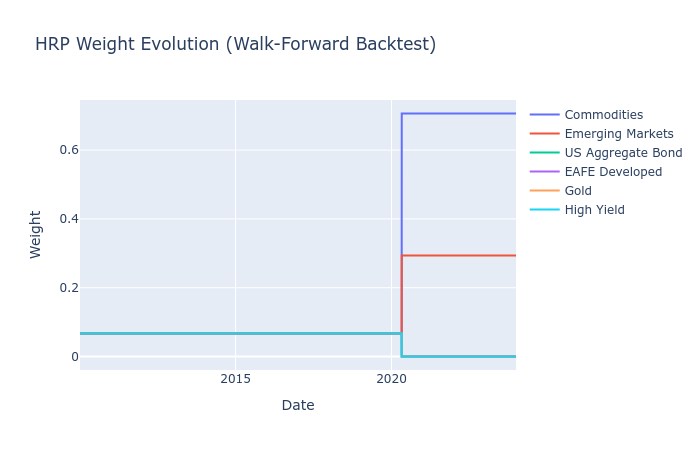

In [41]:
# Plot HRP weight evolution from actual backtest
hrp_weights_hist = weights_all.get("HRP", pd.DataFrame())

if not hrp_weights_hist.empty:
    # Get weight columns
    weight_cols = [c for c in hrp_weights_hist.columns if c.startswith("w_")]

    fig = go.Figure()

    # Show top assets by average weight
    avg_weights = hrp_weights_hist[weight_cols].mean().sort_values(ascending=False)
    top_cols = avg_weights.head(6).index.tolist()

    for col in top_cols:
        symbol = col.replace("w_", "")
        fig.add_trace(
            go.Scatter(
                x=hrp_weights_hist.index,
                y=hrp_weights_hist[col],
                mode="lines",
                name=ETF_UNIVERSE.get(symbol, symbol),
            )
        )

    fig.update_layout(
        title="HRP Weight Evolution (Walk-Forward Backtest)",
        xaxis_title="Date",
        yaxis_title="Weight",
        height=450,
    )
    fig.show()
else:
    print("No HRP weights available")

Weights step rather than drift between rebalance dates because HRP only
re-allocates when the GBM signal triggers a monthly rebalance; the sparse
visible changes reflect that cadence, not within-month covariance updates.

## 12. Why HRP Works in Strategy Context

### Advantages over MVO:

1. **No matrix inversion**: HRP uses recursive bisection instead of inverting the
   covariance matrix, avoiding the amplification of estimation errors.

2. **Respects hierarchical structure**: Markets have a natural hierarchical structure
   (sectors, asset classes, geographies). HRP exploits this structure.

3. **Regime robustness**: When correlations become unstable (e.g., during crises),
   HRP's clustering-based approach is more resilient than MVO.

4. **No expected returns**: HRP is a "risk-based" allocation method that doesn't
   require expected return forecasts, which are notoriously difficult to estimate.

5. **Stable weights**: HRP weights tend to be more stable over time, reducing turnover.

### In Strategy Context:

- HRP is applied to **ML-selected assets**, not the full universe
- Covariance is estimated on **rolling historical windows only**
- Combined with prediction-based selection, HRP provides robust allocation

### Turnover Check

In [42]:
# Turnover comparison from actual backtests
print("Average Monthly Turnover (Walk-Forward Backtest):")
for name in weights_all:
    turnover = allocator_metrics[name]["avg_turnover"]
    print(f"  {name}: {turnover:.2%}")

Average Monthly Turnover (Walk-Forward Backtest):
  Equal Weight: 0.05%
  Inverse Volatility: 0.05%
  Min Variance (LW): 0.05%
  HRP: 0.05%


## Key Takeaways

1. **Clustering avoids matrix inversion**: HRP replaces the covariance matrix inversion
   required by MVO with a clustering-based recursive bisection, eliminating the primary
   source of numerical instability in portfolio optimization.

2. **Empirical comparison on this universe**: On this GBM-selected ETF universe,
   HRP modestly improves on naive diversification: equal-weight Sharpe 0.7763,
   HRP Sharpe 0.8293 (a 0.053 improvement), with HRP also ahead of inverse-volatility
   (0.8074) and trailing only the Ledoit-Wolf minimum-variance allocator (0.8437).
   All four allocators share a ~-28% maximum drawdown, so the differences are in
   risk-adjusted return, not tail risk, and the spreads are small.

3. **Best suited for unstable correlation regimes**: HRP's advantages are most pronounced
   when correlations shift across market regimes. For assets with stable, well-estimated
   covariance structures, simpler methods like inverse volatility may suffice.

**Next**: Continue with [`09_allocator_comparison`](09_allocator_comparison.ipynb) for a controlled, side-by-side comparison
of allocation methods under the same signal and execution assumptions.

### Allocator Fallback Summary

When the allocation function raises (e.g., singular covariance), the
walk-forward backtest falls back to equal weights and increments a counter.

In [43]:
print(f"Assets in universe: {n_assets}")
print(f"Backtest period: {returns.index[0].date()} to {returns.index[-1].date()}")
print(f"Asset selection: ETF GBM walk-forward predictions (hash {ETF_GBM_PRED_HASH})")
if fallback_count:
    print("Allocator fallbacks (singular/invalid covariance):")
    for method_name, count in sorted(fallback_count.items()):
        print(f"  {method_name}: {count}")
else:
    print("Allocator fallbacks: none triggered")

Assets in universe: 15
Backtest period: 2010-01-05 to 2023-12-29
Asset selection: ETF GBM walk-forward predictions (hash e716461a3d25)
Allocator fallbacks: none triggered


In [44]:
metrics_df.round(4)

,Method,Annual Return,Annual Vol,Sharpe Ratio,Max Drawdown,Calmar Ratio
0,Equal Weight,0.1038,0.1398,0.7763,-0.2806,0.3698
1,Inverse Volatility,0.1092,0.1408,0.8074,-0.2806,0.3893
2,Min Variance (LW),0.1183,0.1451,0.8437,-0.2806,0.4215
3,HRP,0.1141,0.1426,0.8293,-0.2806,0.4065
